# **1. Loading the datasets**

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

data_dir = next((path for path in (Path("data"), Path("../data")) if path.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError("Could not find the data directory. Run this notebook from the project root or notebook folder.")

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv", low_memory=False)

In [3]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [4]:
test.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **2.** **Exploratory Data Analysis (EDA)**
## 2.1 Identifying the datatypes and dataset information

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   object 
 13  Spec_VariantModifier       5609 non-null   obj

## 2.2 Performing descriptive statistical analysis on the dataset

In [7]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


In [8]:
test.describe()

,TransactionID,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.500000e+04,1.500000e+04,15000.000000,15000.000000,8809.000000
mean,2.199650e+06,1.199748e+06,7174.697867,1892.378000,4460.034283
std,1.145245e+06,5.277711e+05,7434.103786,305.978851,22541.301953
min,1.139307e+06,1.740000e+02,39.000000,1001.000000,0.000000
25%,1.468021e+06,1.006622e+06,1841.000000,1990.000000,0.000000
50%,1.750341e+06,1.243943e+06,3834.000000,1998.000000,1534.000000
75%,2.372532e+06,1.488693e+06,11645.000000,2004.000000,5023.000000
max,6.333397e+06,2.484757e+06,37208.000000,2015.000000,932000.000000


## 2.3 Identifying missing values (if any)

In [9]:
train.isna().sum()

TransactionID                     0
TargetValue                       0
AssetID                           0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
TransactionDate                   0
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
col4                         128320
DrivetrainType                89956
col5                         128320
col6                        

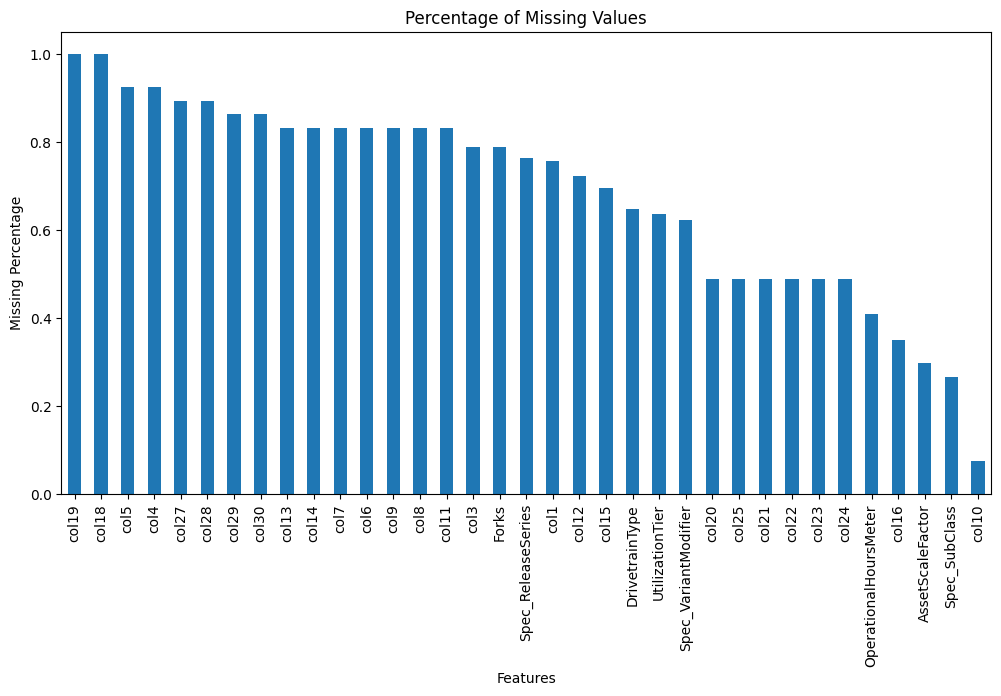

In [10]:
missing = train.isna().mean().sort_values(ascending=False)

missing = missing[missing>0]


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
missing.plot(kind='bar')

plt.title("Percentage of Missing Values")
plt.ylabel("Missing Percentage")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.show()

***Observation:*** *Several variables contain missing values, with OperationalHoursMeter, UtilizationTier, and a few categorical attributes having the highest proportion of missing entries. However, no features contains missing values to the extent it becomes unusable.*

***Inference:*** *Instead of dropping these columns and losing potentially valueable information, appropriate imputation techniques will be applied during preprocessing the data.*

In [11]:
test.isna().sum()

TransactionID                    0
AssetID                          0
ProductConfigID                  0
DataOriginCode                   0
VendorPartnerID                  0
ManufactureYear                  0
OperationalHoursMeter         6191
UtilizationTier               9644
TransactionDate                  0
Spec_FullDescriptor              0
Spec_BaseClass                   0
Spec_SubClass                 3994
Spec_ReleaseSeries           11495
Spec_VariantModifier          9391
AssetScaleFactor              4461
FunctionalClassification         0
RegionCode                       0
InventoryGroupCategory           0
InventoryGroupDescription        0
col1                         11300
CabinType                        0
Forks                        11905
col3                         11919
col4                         13878
DrivetrainType                9739
col5                         13878
col6                         12422
col7                         12422
col8                

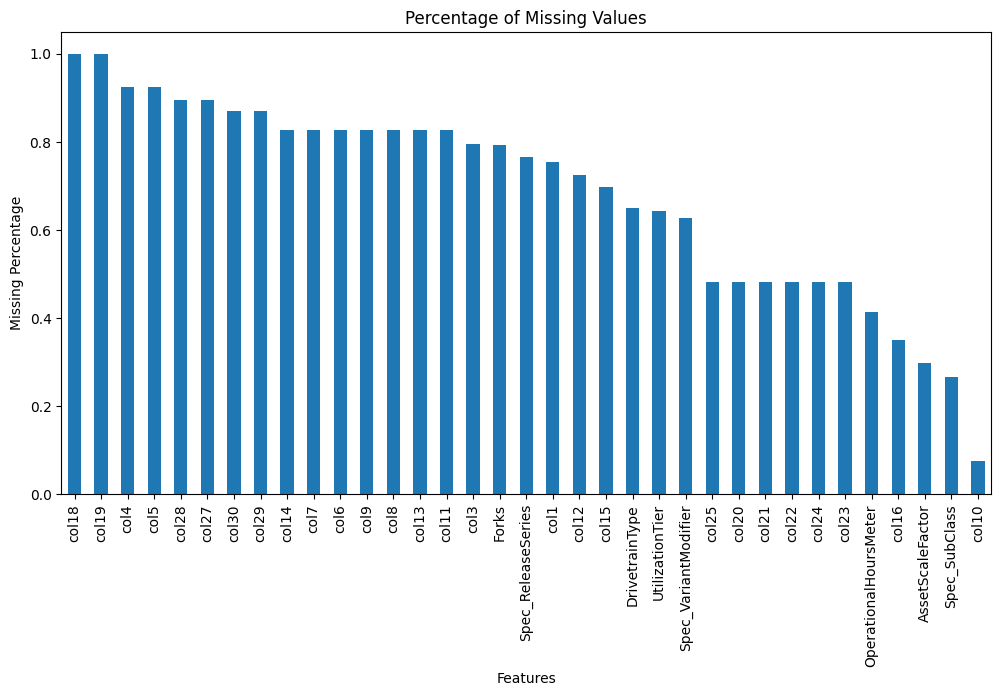

In [12]:
missing = test.isna().mean().sort_values(ascending=False)

missing = missing[missing>0]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
missing.plot(kind='bar')

plt.title("Percentage of Missing Values")
plt.ylabel("Missing Percentage")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.show()

## 2.4 Identifying duplicates (if any)

In [13]:
print("Duplicates in Train Dataset: ", train.duplicated().sum())
print("Duplicates in Test Dataset: ", test.duplicated().sum())

Duplicates in Train Dataset:  0
Duplicates in Test Dataset:  0


## 2.5 Exploring Target Variable

In [14]:
train['TargetValue'].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

In [15]:
train['TargetValue'].skew()

np.float64(0.9699963984208283)

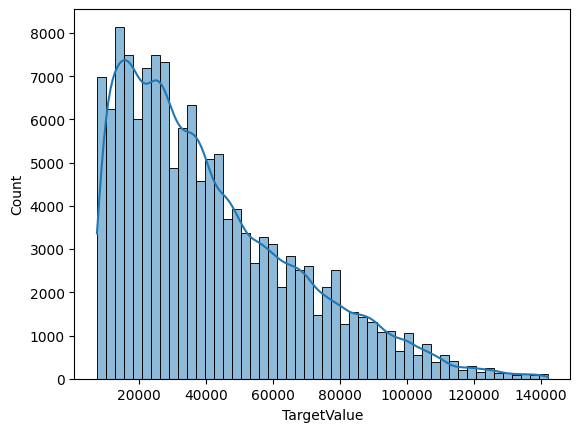

In [16]:
sns.histplot(train['TargetValue'], bins=50, kde=True)
plt.show()

***Observation:*** *The selling price (TargetValue) is positivelu skewed, with a large number of machines sold at lower prices and relatively fewer extremely expensive machines.*

***Inference:*** *Since the competition uses RMSLE as the evaluation metric, a log1p() transformation is applied to reduce skewness, stabilise variance, and reduce the influence of high-value observations during model training.*

# **3.** **Data Visualizations**

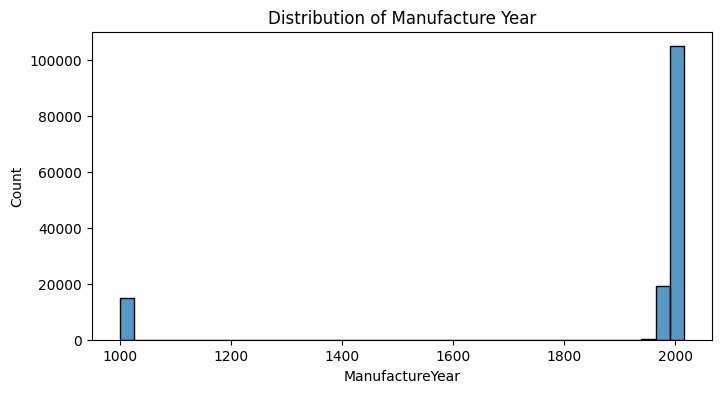

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(train['ManufactureYear'], bins=40)

plt.title('Distribution of Manufacture Year')
plt.show()

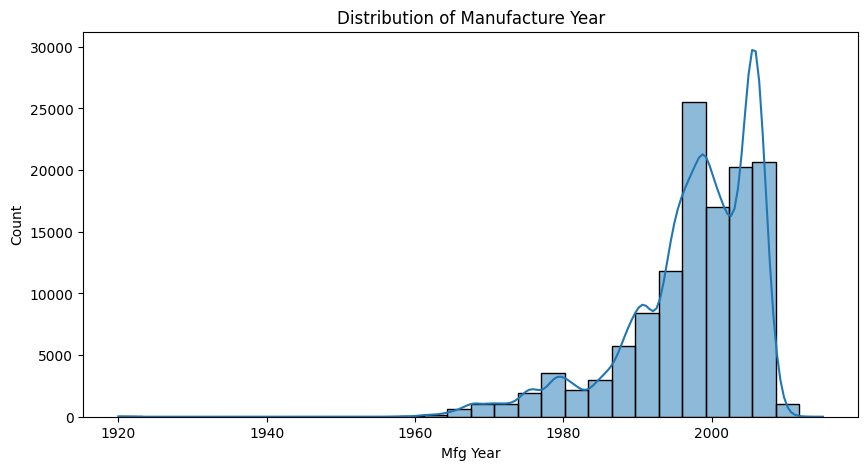

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(train.loc[train['ManufactureYear']>1900, 'ManufactureYear'], bins=30, kde=True)

plt.title('Distribution of Manufacture Year')
plt.xlabel('Mfg Year')
plt.ylabel("Count")
plt.show()

## 3.1 Feature engineering to extract meaningful datapoints

In [19]:
def extract_date(df):
    df = df.copy()
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['TransactionYear'] = df['TransactionDate'].dt.year
    df['TransactionMonth'] = df['TransactionDate'].dt.month
    df['TransactionQuarter'] = df['TransactionDate'].dt.quarter
    return df

In [20]:
train = extract_date(train)
test = extract_date(test)

In [21]:
train['AssetAge'] = (train['TransactionYear'] - train['ManufactureYear'])
test['AssetAge'] = (test['TransactionYear'] - test['ManufactureYear'])

<Axes: xlabel='AssetAge', ylabel='TargetValue'>

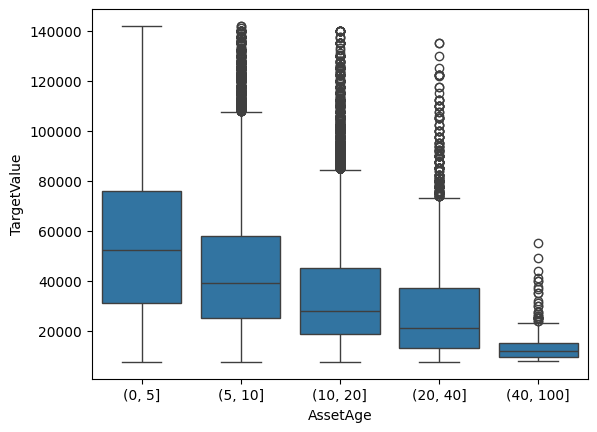

In [22]:
sns.boxplot(x=pd.cut(train['AssetAge'],
                     bins = [0, 5, 10, 20, 40, 100]),
               y=train['TargetValue'])

***Observation:*** *Machines with lower AssetAge generally command higher sale prices, while older machinery tends to sell for lesser prices.*

***Inference:*** *AssetAge captures depreciation more effectively than manufacture year alone and is therefore included as an engineered feature.*

<Axes: xlabel='OperationalHoursMeter', ylabel='Count'>

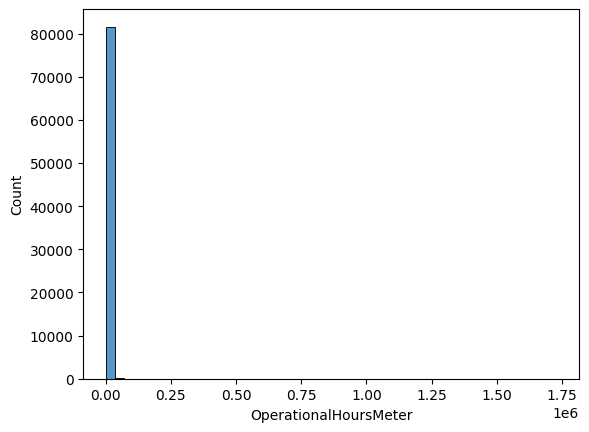

In [23]:
sns.histplot(train['OperationalHoursMeter'].dropna(), bins=50)

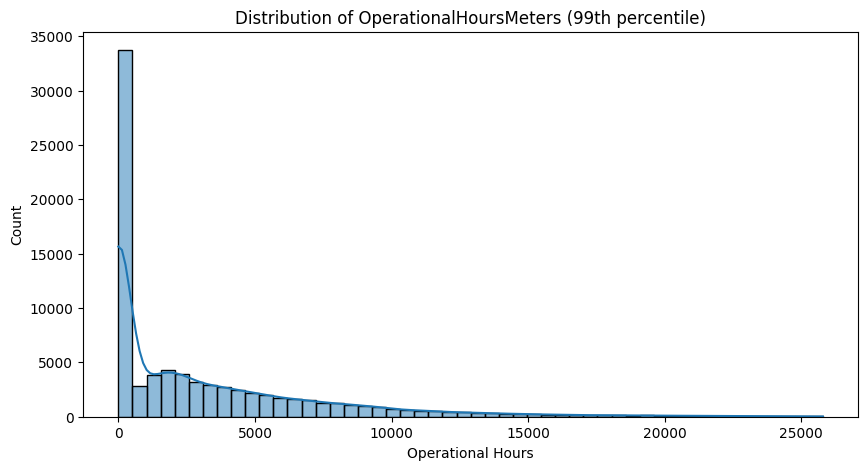

In [24]:
hours = train['OperationalHoursMeter'].dropna()

plt.figure(figsize=(10,5))
sns.histplot(hours[hours <= hours.quantile(0.99)],
            bins=50,
            kde=True)

plt.title("Distribution of OperationalHoursMeters (99th percentile)")
plt.xlabel("Operational Hours")
plt.ylabel("Count")
plt.show()

***Observation:*** *The distribution of operational hours is highly right-skewed. Most machines have relatively low recorded operating hours, while a small number have extremely high values.*
***Inference:*** *To better visualize the typical distribution, the histogram is restricted to the 99th percentile. The presence of outliers suggests that the median is a more appropriate imputation statistics than the mean for this feature.*

In [25]:
train["OperationalHoursMeter"].describe(percentiles=[0.90, 0.95, 0.99])

count    8.205800e+04
mean     4.553719e+03
std      2.792204e+04
min      0.000000e+00
50%      1.620000e+03
90%      9.348000e+03
95%      1.303100e+04
99%      2.579601e+04
max      1.729600e+06
Name: OperationalHoursMeter, dtype: float64

<Axes: xlabel='OperationalHoursMeter', ylabel='TargetValue'>

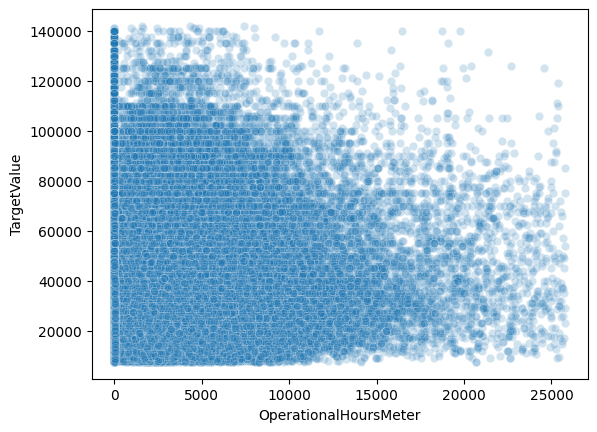

In [26]:
sns.scatterplot(x=hours[hours <= hours.quantile(0.99)], y=train['TargetValue'], alpha=0.2)

***Observation:*** *Machines with lower operational hours generally tend to have higher resale values, although the relationship is not perfectly linear.*

***Inference:*** *Operational hours provide useful information regarding machine usage and condition, making this an important predictive feature.*

<Axes: xlabel='RegionCode'>

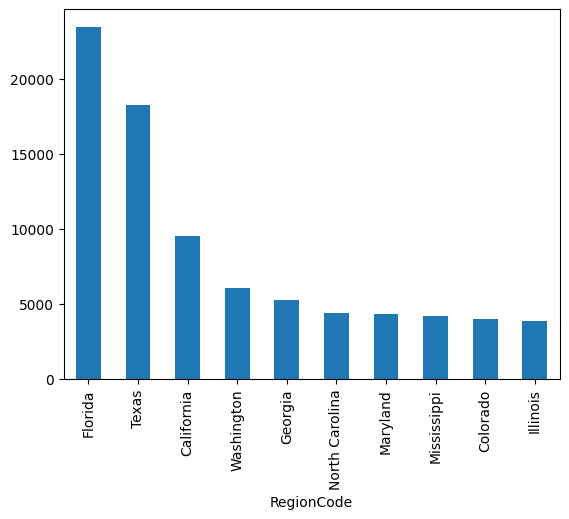

In [27]:
train['RegionCode'].value_counts().head(10).plot(kind='bar')

***Observation:*** *Machinery sales are concentrated in a few regions such as Florida, Texas, California, etc. While several other regions contribute realatively fewer transactions.*

***Inference:*** *Regional differences may reflect local market demand, and pricing behaviour, therefore, RegionCode is retained as a categorical predictor.*

## 3.2 Feature engineering to clean the data

In [28]:
def clean_features(df):
    df = df.copy()

    df['HasOperationalHours'] = (df['OperationalHoursMeter'].notna().astype(int))

    df['HasVariantModifier'] = (df['Spec_VariantModifier'].notna().astype(int))

    return df

In [29]:
train = clean_features(train)
test = clean_features(test)

In [30]:
train['DescriptorLength'] = (train['Spec_FullDescriptor'].fillna('').astype(str).str.len())
test['DescriptorLength'] = (test['Spec_FullDescriptor'].fillna('').astype(str).str.len())

In [31]:
train.drop(columns=['TransactionDate'], inplace=True)
test.drop(columns=['TransactionDate'], inplace=True)

<Axes: >

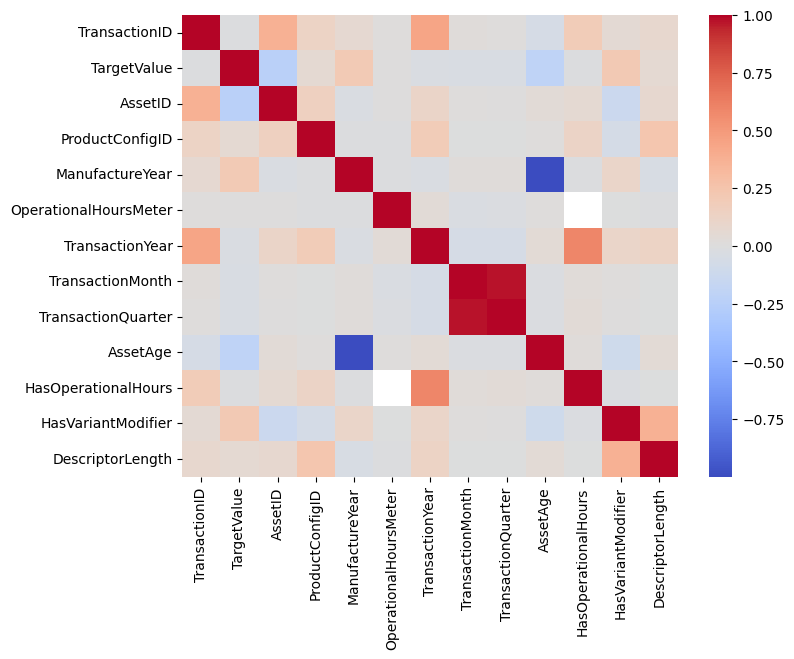

In [32]:
numeric = train.select_dtypes(include=np.number)

corr = numeric.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', center=0)

***Observation:*** *Most numerical variables exhibit relatively weaker linear correlations with target variable, indicating that the selling price is influenced by multiple interacting factors rather than a single dominant predictor.Strong correlations observed between engineered features(eg, Transaction Quarter, Manufacture Year and AssetAge) are expected because one feature is derived from the other.*

***Inference:*** *The weak pairwise correlations suggest that ensemble tree-based models such as RandomForest and LightGBM are appopriate, as they can effectively capture complex, non-linear relationships that simple linear models may fail to model.*

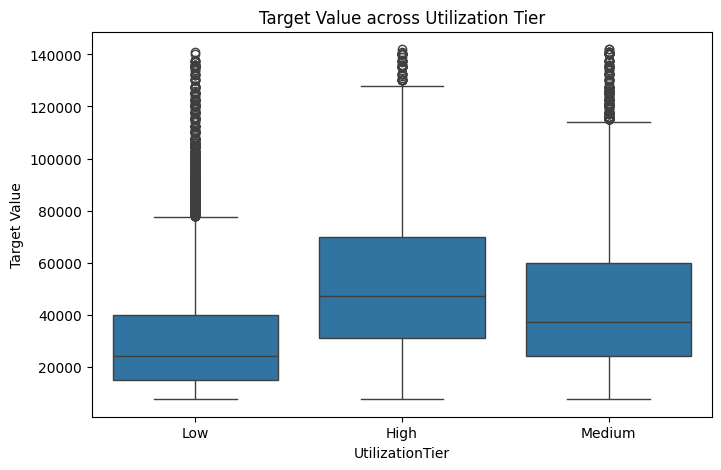

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train,
           x='UtilizationTier',
           y='TargetValue')

plt.title("Target Value across Utilization Tier")
plt.xlabel("UtilizationTier")
plt.ylabel('Target Value')

plt.show()

***Observation:*** *The resale price varies across different utilization tiers, indicating that machinery usage patterns influence market value.*

***Inference:*** *Since different utilization levels exhibit different price distributions, UtilizationTier is retained as a categorical predictor and encoded during preprocessing.*

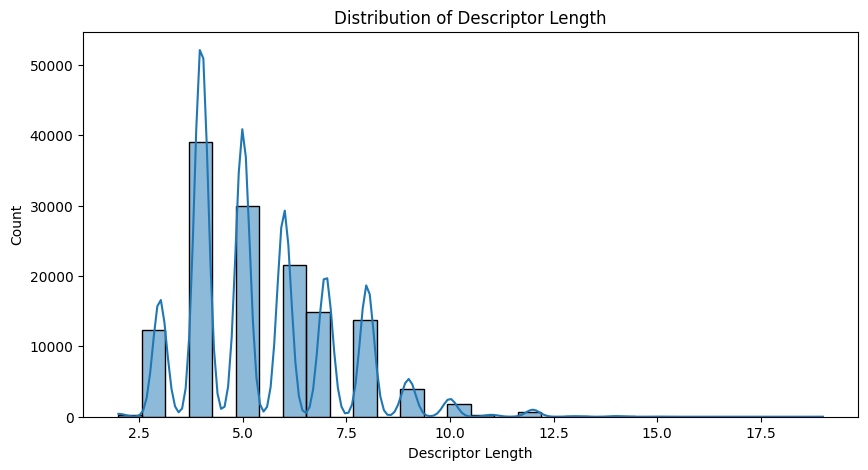

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(train['DescriptorLength'],
            bins=30,
            kde=True)

plt.title("Distribution of Descriptor Length")
plt.xlabel("Descriptor Length")
plt.ylabel("Count")

plt.show()

***Observation:*** *Most machinery descriptors fall withing a moderate range of descriptor lengths, while only a small number contain exceptionally long specifications.*

***Inference:*** *The descriptor length serves as a simple proxy for the amount of technical info available about a machine. More detailed specs may indicate specialized equipment, potentially influencing resale value. Therefore DescriptorLength is included as an engineered feature.*

## **3.3 Key Insights from EDA**

The exploratory analysis revealed several patterns that guided the feature engineering process:
1. The target variable is positively skewed, motivating the use of log transformation before model training.
2. Older machinery usually exhibits lower resale prices, leading to the creation of the AssetAge feature.
3. Opeartional Hours are highly skewed and contain extreme outliers, making median imputation more appropriate than the mean imputation strategy.
4. Difference in resale prices across utilization tiers suggest that machine usage characteristics influence market value.
5. The varying lengths of machine descriptions indicate differing levels of specification detail, motivating the creation of the DescriptorLength feature.

Based on these observations, new features were engineered to better represent machine characteristics and improve predictive performance.

# **4. Data Preprocessing**

In [35]:
train['TargetValue'].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

In [36]:
train['TargetValue'].skew()

np.float64(0.9699963984208283)

In [37]:
X = train.drop(columns=['TargetValue'])
y = np.log1p(train['TargetValue'])

X_test = test.copy()

## 4.1 Imputing the data

In [38]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical columns: {len(num_cols)}")

Categorical columns: 43
Numerical columns: 12


In [39]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, random_state=42, test_size = 0.2
)

X_train.shape, X_val.shape

((110960, 55), (27741, 55))

In [41]:
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [42]:
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

## 4.2 Encoding the data

In [43]:
from sklearn.preprocessing import OrdinalEncoder

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.int64,
)

if cat_cols:
    X_train_encoded = categorical_encoder.fit_transform(X_train[cat_cols])
    X_val_encoded = categorical_encoder.transform(X_val[cat_cols])
    X_test_encoded = categorical_encoder.transform(X_test[cat_cols])
    for index, column in enumerate(cat_cols):
        X_train[column] = X_train_encoded[:, index]
        X_val[column] = X_val_encoded[:, index]
        X_test[column] = X_test_encoded[:, index]

In [44]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print("\nRemaining Missing values:")
print(X_train.isna().sum().sum())
print(X_val.isna().sum().sum())
print(X_test.isna().sum().sum())

(110960, 55)
(27741, 55)
(15000, 55)

Remaining Missing values:
0
0
0


# **5. Model Building**

## 5.1 First Model: Decision Tree Regressor

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_log_error

dt_model = DecisionTreeRegressor(max_depth=15,
                                min_samples_split=20,
                                random_state=42)

dt_model.fit(X_train, y_train)
dt_pred_log = dt_model.predict(X_val)
dt_pred = np.expm1(dt_pred_log)
y_val_actual = np.expm1(y_val)
dt_rmsle = root_mean_squared_log_error(y_val_actual, dt_pred)
print(f"Decision Tree Validation RMSLE: {dt_rmsle:.4f}")

Decision Tree Validation RMSLE: 0.2680


## 5.2 Second Model: CatBoostRegressor

In [46]:

from catboost import CatBoostRegressor

cat_features = X_train.select_dtypes(include='object').columns.tolist()
cat_model = CatBoostRegressor(iterations=500,
                             learning_rate=0.05,
                             depth=8,
                             loss_function='RMSE',
                             eval_metric='RMSE',
                             random_seed=42,
                             verbose=100)

cat_model.fit(X_train, y_train, cat_features=cat_features)
cat_pred_log = cat_model.predict(X_val)
cat_pred = np.expm1(cat_pred_log)
cat_rmsle=root_mean_squared_log_error(y_val_actual, cat_pred)
print(f"CatBoost Validation RMSLE: {cat_rmsle:.5f}")

0:	learn: 0.6502785	total: 91.9ms	remaining: 45.8s
100:	learn: 0.2904650	total: 4.87s	remaining: 19.2s
200:	learn: 0.2614284	total: 8.13s	remaining: 12.1s
300:	learn: 0.2460587	total: 12.9s	remaining: 8.55s
400:	learn: 0.2364140	total: 17.1s	remaining: 4.22s
499:	learn: 0.2292941	total: 20.1s	remaining: 0us
CatBoost Validation RMSLE: 0.23368


## 5.3 Third Model: LightGBMRegressor

In [47]:
import lightgbm as lbg

lbg_model = lbg.LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators = 12000,
    random_state=42,
    n_jobs=-1
)

lbg_model.fit(X_train, y_train)
lbg_pred_log = lbg_model.predict(X_val)
lbg_pred = np.expm1(lbg_pred_log)
y_val_actual = np.expm1(y_val)
lbg_rmsle = root_mean_squared_log_error(y_val_actual, lbg_pred)
print(f"LightGBM Regressor Validation RMSLE: {lbg_rmsle:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.737253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2384
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 55
[LightGBM] [Info] Start training from score 10.424734
LightGBM Regressor Validation RMSLE: 0.2060


# **6. Hyperparameter Tuning the third model - LightGBMRegressor**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "num_leaves": [127, 255],
    "learning_rate": [0.02, 0.03],
    "min_child_samples": [5, 10]
}

base_model = lbg.LGBMRegressor(
    metric="rmse",
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(estimator=base_model,
                                  param_distributions=param_dist,
                                  n_iter = 3,
                                  scoring="neg_root_mean_squared_error",
                                  cv=3,
                                  random_state=42,
                                  verbose=1,
                                  n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

best_params = random_search.best_params_



Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.712068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 73974, number of used features: 55
[LightGBM] [Info] Start training from score 10.425803
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.425656 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2355
[LightGBM] [Info] Number of data points in the train set: 73973, number of used features: 55
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.421283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

KeyboardInterrupt: 

Bad pipe message: %s [b'ecure-Requests: 1\r\nUser-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Geck', b' Code/1.140.0 Chrome/150.0.7871.250 Electron/43.7.3 Safari/537.36\r\nAccept: text/html,application/xhtml+xml,app', b'cation/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7\r\nSec-Fet', b'-Site: none\r\nSec-Fetch-Mode: navigate\r\nSec-Fetch-User: ?1\r\nSec-Fetch-Dest: document\r\nAccept-Encodi']


In [ ]:
model = lbg.LGBMRegressor(objective="regression",
                          metric='rmse',
                          n_estimators=12000,
                          learning_rate=0.02,
                          num_leaves=255,
                          max_depth=-1,
                          min_child_samples=5,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          reg_alpha=0.1,
                          reg_lambda=0.1,
                          random_state=42,
                          n_jobs=-1)

model.fit(X_train, y_train,
         eval_set=[(X_val, y_val)],
         eval_metric="rmse",
         callbacks=[
             lbg.early_stopping(300),
             lbg.log_evaluation(100)
         ])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2384
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 55
[LightGBM] [Info] Start training from score 10.424734
Training until validation scores don't improve for 300 rounds
[100]	valid_0's rmse: 0.269925
[200]	valid_0's rmse: 0.231745
[300]	valid_0's rmse: 0.220569
[400]	valid_0's rmse: 0.214832
[500]	valid_0's rmse: 0.21193
[600]	valid_0's rmse: 0.210138
[700]	valid_0's rmse: 0.208878
[800]	valid_0's rmse: 0.207857
[900]	valid_0's rmse: 0.206937
[1000]	valid_0's rmse: 0.206264
[1100]	valid_0's rmse: 0.205731
[1200]	valid_0's rmse: 0.205225
[1300]	valid_0's rmse: 0.204704
[1400]	valid_0's rmse: 0.204281
[1500]	valid_0's rmse: 0.203942
[1600]	valid_0's rmse: 0.203631
[1700]	valid_0's rmse: 0.203

In [ ]:
val_pred_log=model.predict(X_val)

NameError: name 'model' is not defined

In [ ]:
val_pred = np.expm1(val_pred_log)
y_val_actual =np.expm1(y_val)

In [ ]:
from sklearn.metrics import mean_squared_log_error
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [ ]:
score = rmsle(y_val_actual, val_pred)
print(f"Validation RMSLE: {score:.5f}")

In [ ]:
test_pred_log = model.predict(X_test)
test_pred = np.expm1(test_pred_log)

test_pred = np.maximum(test_pred, 0)

# **7. Comparing the models**

In [ ]:
comparison = pd.DataFrame({
    "Model" : ["Decision Tree", "CatBoost", "LightGBM"],
    "Validation_RMSLE": [dt_rmsle, cat_rmsle, score]
})

comparison = comparison.sort_values("Validation_RMSLE")
comparison

## 7.1 Visualizing the model performance

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(comparison['Model'], comparison['Validation_RMSLE'])

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Validation_RMSLE")

for i, v in enumerate(comparison['Validation_RMSLE']):
    plt.text(i, v+0.002, f"{v:.4f}", ha='center')

plt.show()

In [ ]:
custom_sample = X_train.iloc[[0]].copy()

custom_sample['AssetAge'] = 5.0
custom_sample['OperationalHoursMeter'] = 2500.0
custom_sample['ManufactureYear'] = 2010

custom_pred_log = model.predict(custom_sample)
custom_pred_price = np.expm1(custom_pred_log)[0]

print(f"Predicted selling price for your custom machine configuration: ${custom_pred_price:,.2f}")

In [ ]:
import joblib

project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
model_path = project_root / "model_bundle.pkl"
model_bundle = {
    "model": model,
    "feature_columns": X_train.columns.tolist(),
    "numerical_columns": num_cols,
    "categorical_columns": cat_cols,
    "numerical_imputer": num_imputer,
    "categorical_imputer": cat_imputer,
    "categorical_encoder": categorical_encoder,
}
joblib.dump(model_bundle, model_path)
print(f"Saved model and preprocessing artifacts to {model_path}")

In [ ]:
model_bundle = joblib.load(model_path)
model = model_bundle["model"]

In [ ]:
custom_sample = X_train.iloc[[0]].copy()

custom_sample['AssetAge'] = 1.0
custom_sample['OperationalHoursMeter'] = 2000.0
custom_sample['ManufactureYear'] = 2010

custom_pred_log = model.predict(custom_sample)
custom_pred_price = np.expm1(custom_pred_log)[0]

print(f"Predicted selling price for your custom machine configuration: ${custom_pred_price:,.2f}")